In [1]:
import os
import sys
os.environ['PYTHONWARNINGS'] = 'ignore'
class NullWriter:
    def write(self, msg):
        pass
    def flush(self):
        pass
sys.stderr = NullWriter()

In [2]:
import scanpy as sc
import matplotlib.pyplot as plt
import celldyc as cdc

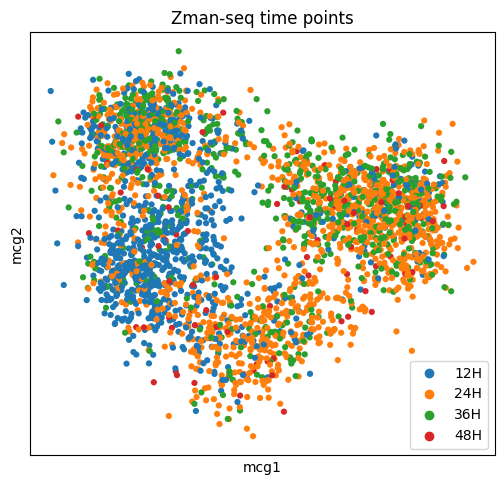

  0%|          | 0/3108 [00:00<?, ?cells/s]

computing velocity graph
finished.


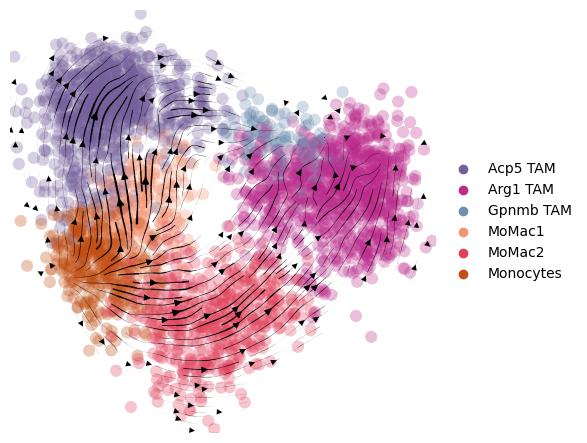

computing velocity embedding
finished.


In [3]:
# Reproduce CellDyc’s analysis results on the gbm_mono2tam dataset.
adata = sc.read_h5ad('celldyc_gbm_mono2tam.h5ad')
fig, ax = plt.subplots(figsize=(6, 5.5))
ax = sc.pl.embedding(
    adata,
    color=["time_assignment"],  
    basis="mcg",              
    ax=ax,
    title="Zman-seq time points",                 
    legend_loc="lower right",  
    s=80                      
)
cdc.pl.plot_velocity_projection(
    adata,  
    basis="mcg",            
    color='cluster_colors',                        
    legend_loc="right",  
    figsize=(5.5, 5.5)          
)

## We provide the complete code for running the CellDyc model below; however, due to variations in hardware configurations and runtime environments, the resulting outputs may exhibit minor discrepancies.
# adata = cdc.datasets.mono2tam()
# print(adata)
# fig, ax = plt.subplots(figsize=(6, 5.5))
# ax = sc.pl.embedding(
#     adata,
#     color=["time_assignment"],  
#     basis="mcg",              
#     ax=ax,
#     title="Zman-seq time points",                 
#     legend_loc="lower right",  
#     s=80                      
# )
# cat_map = {'12H': 12, '24H': 24, '36H': 36, '48H': 48}
# adata.obs['zmanseq_time'] = adata.obs['time_assignment'].map(cat_map).astype(int).astype('category')
# adata = cdc.tl.preprocess(adata)
# cdc.tl.recover_dyc(adata, time_key="zmanseq_time", time_weight=0.001)
# cdc.pl.plot_velocity_projection(
#     adata,  
#     basis="mcg",            
#     color='cluster_colors',                        
#     legend_loc="right",  
#     figsize=(5.5, 5.5)          
# )


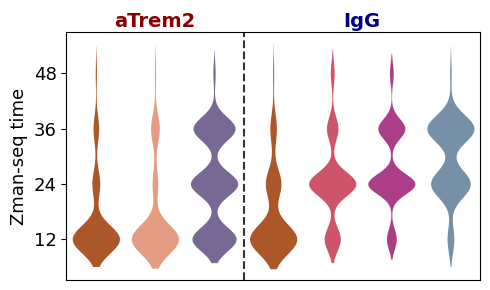

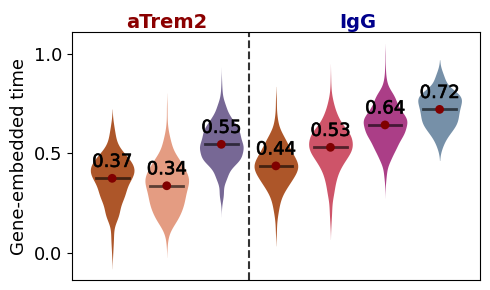

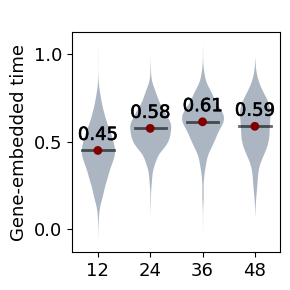

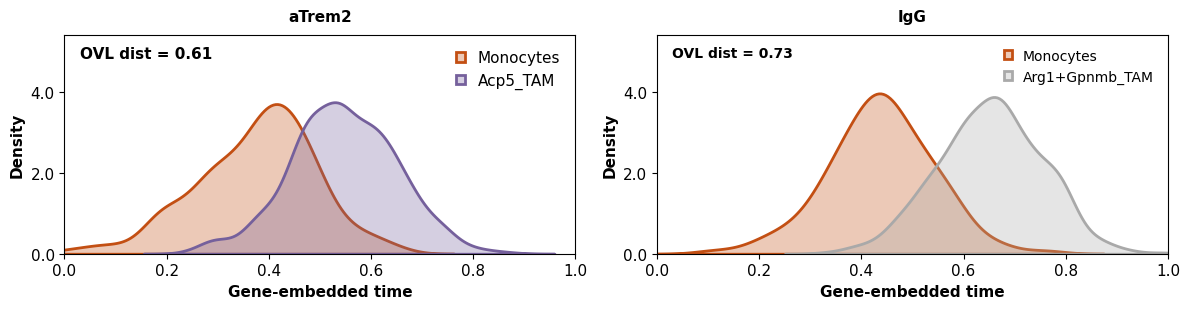

aTrem2 - OVL dist: 0.61
IgG - OVL dist: 0.73


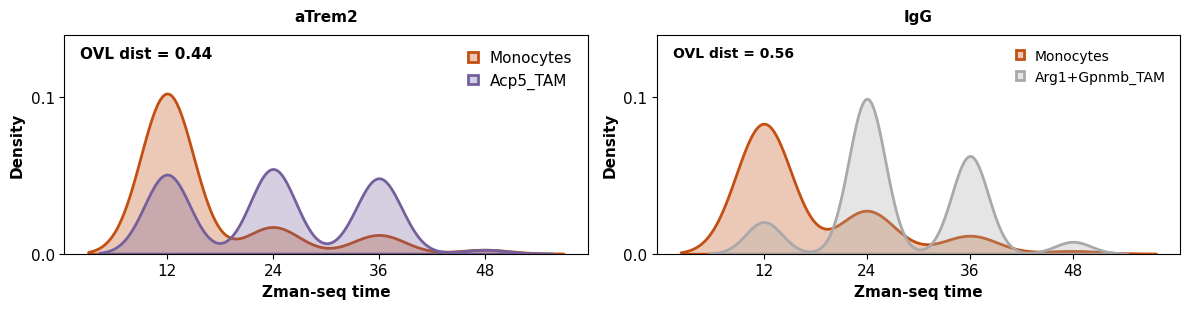

aTrem2 - OVL dist: 0.44
IgG - OVL dist: 0.56
Gene analysis complete. Total genes: 2000
Balanced group: 9
IgG-preferential group: 4


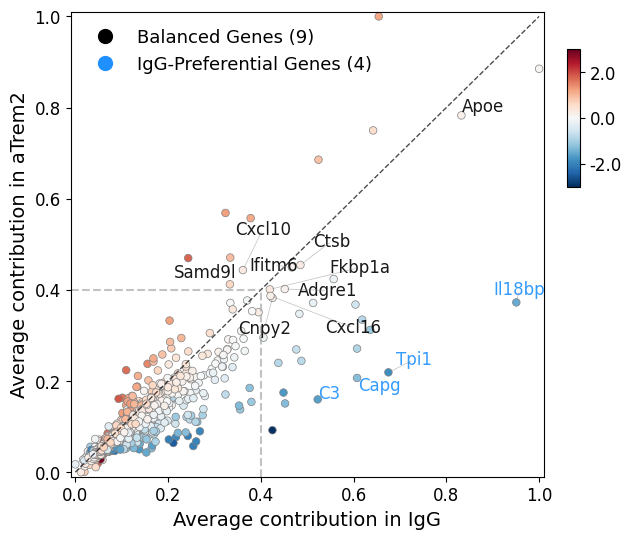

Genes above diagonal: 156 (7.8%)
Genes below diagonal: 1844 (92.2%)
Total genes: 2000


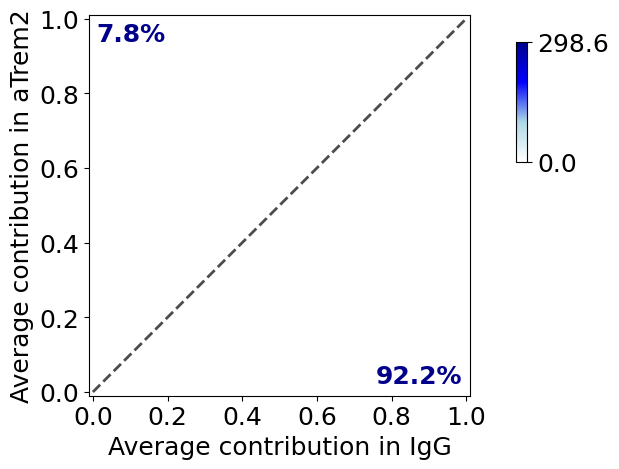

Selected data shape: (3108, 13)


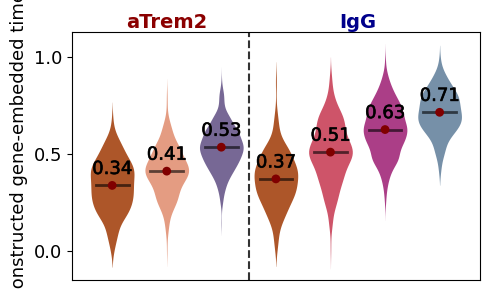

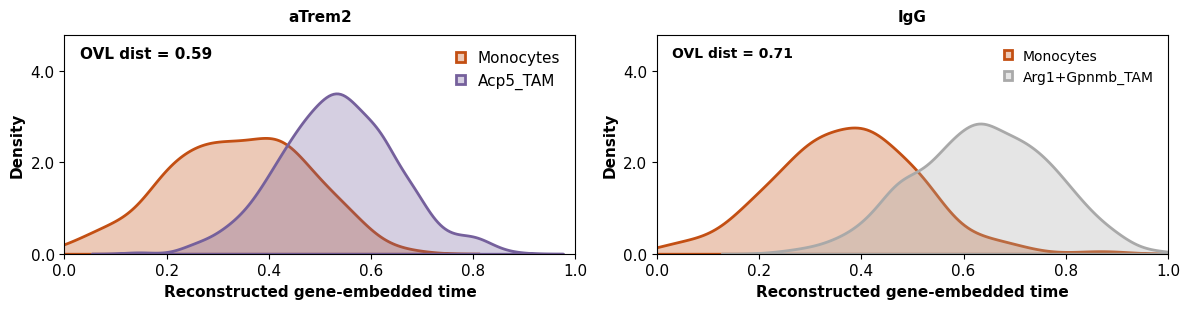

aTrem2 - OVL dist: 0.59
IgG - OVL dist: 0.71
Selected data shape: (3108, 9)


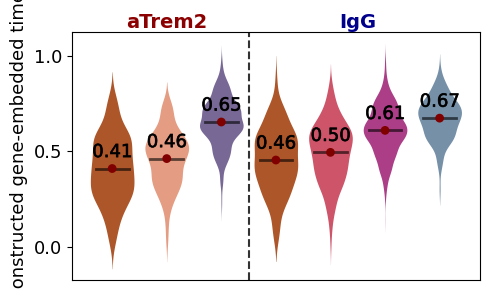

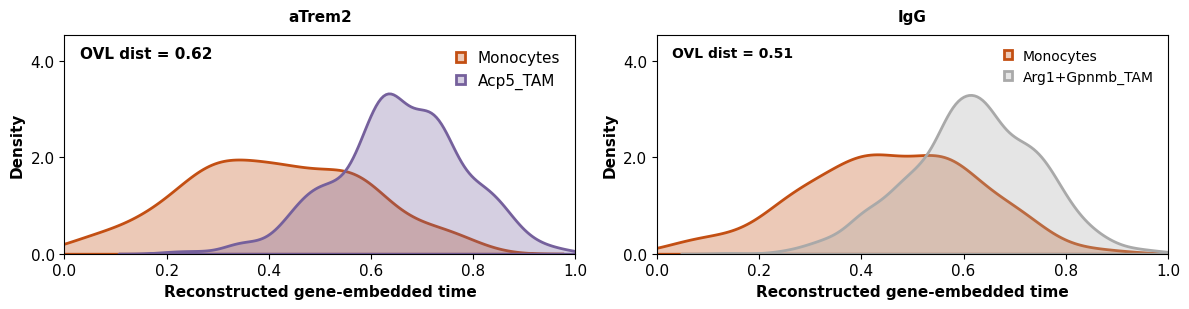

aTrem2 - OVL dist: 0.62
IgG - OVL dist: 0.51
Selected data shape: (3108, 4)


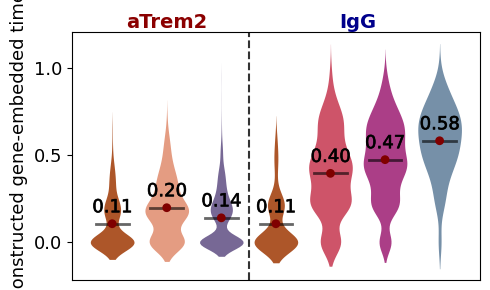

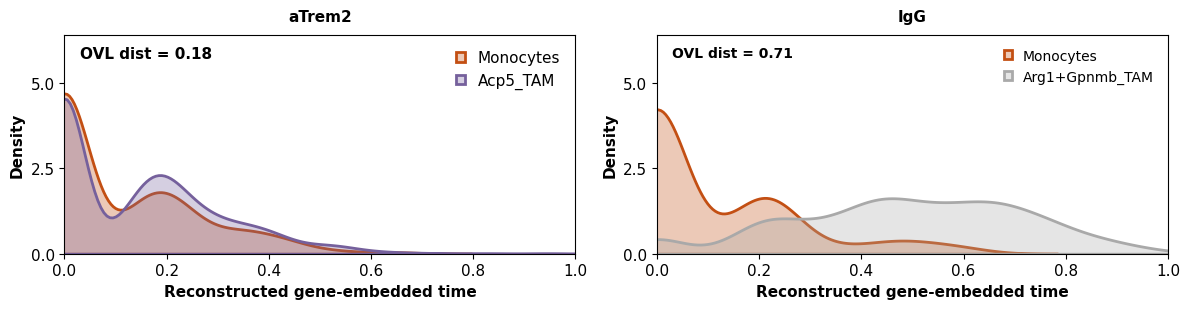

aTrem2 - OVL dist: 0.18
IgG - OVL dist: 0.71


In [4]:
cdc.rp.getime_violin_mono2tam(
    adata=adata,
    value_col='zmanseq_time',
    ylabel='Zman-seq time',
    show_means=False,
    title=" ",
    group_type='cluster'
)
cdc.rp.getime_violin_mono2tam(
    adata=adata,
    value_col='getime',
    ylabel='Gene-embedded time',
    show_means=True,
    title=" ",
    group_type='cluster'
)
cdc.rp.getime_violin_mono2tam(
    adata=adata,
    value_col='getime',
    ylabel='Gene-embedded time',
    show_means=True,
    title=" ",
    group_type='zmanseq_time'
)
cdc.rp.getime_density(
    adata=adata,
    xlabel='Gene-embedded time'
)
cdc.rp.getime_density(
    adata=adata,
    xlabel='Zman-seq time'
)
results_df = cdc.rp.analyze_gene_contributions(adata.copy())
cdc.rp.plot_contrib_comparison(results_df)
cdc.rp.plot_gene_density(results_df)

mask=cdc.rp.mask_getime_genes(adata.copy(),group="all")
adata_=cdc.rp.remake_getime(adata.copy(),mask)
cdc.rp.getime_violin_mono2tam(
    adata=adata_,
    value_col='remake_getime',
    ylabel='Reconstructed gene-embedded time',
    show_means=True,
    title=" ",
    group_type='cluster'
)
cdc.rp.getime_density(
    adata=adata_,
    xlabel='Reconstructed gene-embedded time'
)
mask=cdc.rp.mask_getime_genes(adata.copy(),group="balanced")
adata_=cdc.rp.remake_getime(adata.copy(),mask)
cdc.rp.getime_violin_mono2tam(
    adata=adata_,
    value_col='remake_getime',
    ylabel='Reconstructed gene-embedded time',
    show_means=True,
    title=" ",
    group_type='cluster'
)
cdc.rp.getime_density(
    adata=adata_,
    xlabel='Reconstructed gene-embedded time'
)
mask=cdc.rp.mask_getime_genes(adata.copy(),group="igg-preferential")
adata_=cdc.rp.remake_getime(adata.copy(),mask)
cdc.rp.getime_violin_mono2tam(
    adata=adata_,
    value_col='remake_getime',
    ylabel='Reconstructed gene-embedded time',
    show_means=True,
    title=" ",
    group_type='cluster'
)
cdc.rp.getime_density(
    adata=adata_,
    xlabel='Reconstructed gene-embedded time'
)

Saved to: data\gbm_mono2tam.h5ad


  0%|          | 0/3 [00:00<?, ?time pair/s]

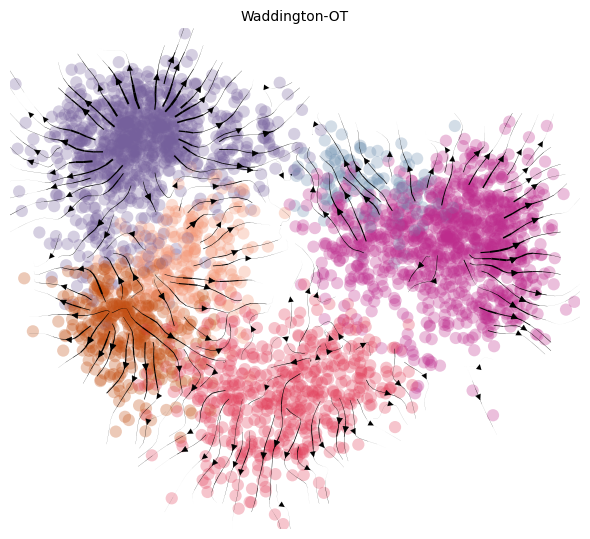

In [5]:
import cellrank as cr
import moscot as mt
import wot

adata_wot = cdc.datasets.mono2tam()
cat_map = {'12H': 12, '24H': 24, '36H': 36, '48H': 48}
adata_wot.obs['zmanseq_time'] = adata_wot.obs['time_assignment'].map(cat_map).astype(int).astype('category')
adata_wot = cdc.tl.preprocess(adata_wot)
adata_moscot = adata_wot.copy()
ot_model = wot.ot.OTModel(adata_wot, day_field="zmanseq_time")
ot_model.compute_all_transport_maps(tmap_out="R4/")
vk = cr.kernels.RealTimeKernel.from_wot(adata_wot, path="R4/", time_key="zmanseq_time")
vk.compute_transition_matrix()
vk.plot_projection(basis="mcg",connectivities=adata_wot.obsp["connectivities"],color=['cluster_colors'],title="Waddington-OT",colorbar=False,show=False,legend_loc="none",figsize=(6, 5.5))
ax = plt.gca()
ax.grid(False)
plt.tight_layout()
plt.show()

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Solving `3` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(1267, 783)].                                   
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(964, 1267)].                                   
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(783, 94)].                                     


  0%|          | 0/3 [00:00<?, ?time pair/s]

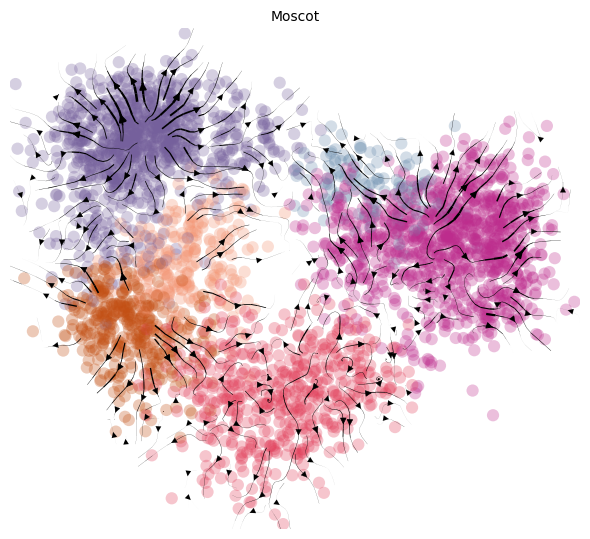

In [6]:
adata_moscot.obs['zmanseq_time'] = adata_moscot.obs['zmanseq_time'].astype('category')
tp = mt.problems.TemporalProblem(adata_moscot)
tp = tp.prepare(time_key="zmanseq_time").solve()
vk = cr.kernels.RealTimeKernel.from_moscot(tp)
vk.compute_transition_matrix()
vk.plot_projection(basis="mcg",connectivities=adata_moscot.obsp["connectivities"],color=['cluster_colors'],title="Moscot",colorbar=False,show=False,legend_loc="none",figsize=(6, 5.5))
ax = plt.gca()
ax.grid(False)
plt.tight_layout()
plt.show()